<a href="https://colab.research.google.com/github/tu25002-4828-alt/EU_M_Math-Repository/blob/main/Chap03_Cm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
mkdir chap3

In [9]:
cd ./chap3

/content/chap3


In [10]:
import requests, zipfile
import io
import urllib3

urllib3.disable_warnings()

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00356/student.zip'

r = requests.get(url, stream=True, verify=False)

z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall()

In [11]:
ls

student-mat.csv  student-merge.R  student-por.csv  student.txt


In [13]:
import pandas as pd
student_data_math = pd.read_csv('student-mat.csv')

In [14]:
import pandas as pd
import requests
import io
import urllib3

# SSL警告を無効化
urllib3.disable_warnings()

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

# verify=False でSSL検証を無効化
r = requests.get(url, verify=False)

# CSV読み込み
wine = pd.read_csv(io.StringIO(r.text), sep=';')

# 確認
print(wine.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count    1599.000000       1599.000000  1599.000000     1599.000000   
mean        8.319637          0.527821     0.270976        2.538806   
std         1.741096          0.179060     0.194801        1.409928   
min         4.600000          0.120000     0.000000        0.900000   
25%         7.100000          0.390000     0.090000        1.900000   
50%         7.900000          0.520000     0.260000        2.200000   
75%         9.200000          0.640000     0.420000        2.600000   
max        15.900000          1.580000     1.000000       15.500000   

         chlorides  free sulfur dioxide  total sulfur dioxide      density  \
count  1599.000000          1599.000000           1599.000000  1599.000000   
mean      0.087467            15.874922             46.467792     0.996747   
std       0.047065            10.460157             32.895324     0.001887   
min       0.012000             1.000000         

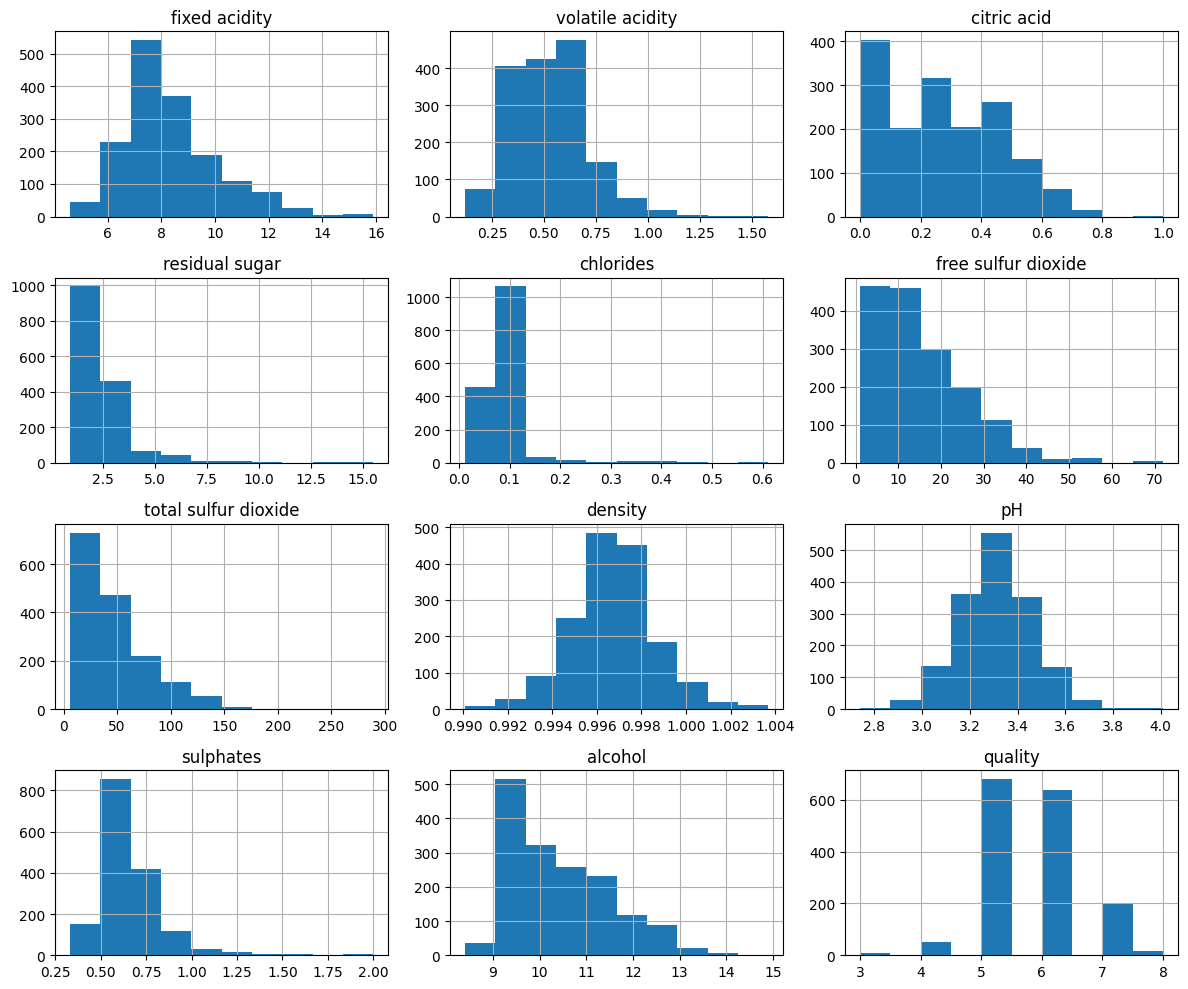

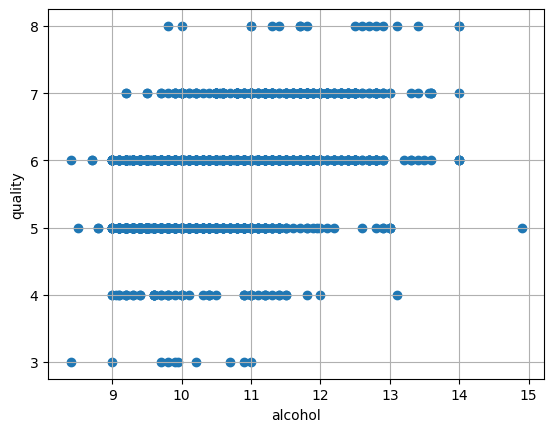

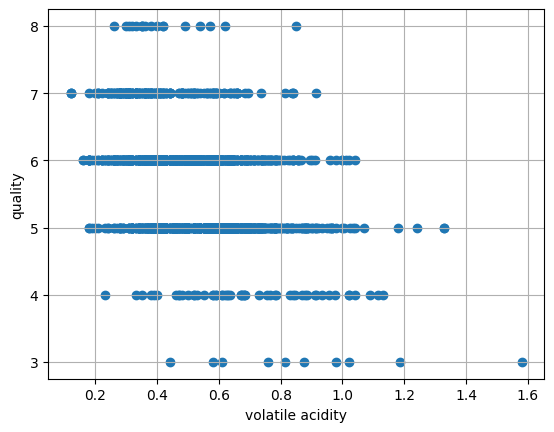

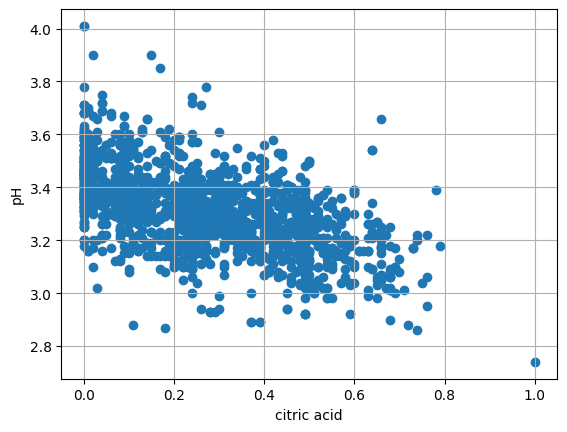

In [15]:
import pandas as pd
import requests
import io
import urllib3
import matplotlib.pyplot as plt

# SSL警告を無効化
urllib3.disable_warnings()

# データ取得
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv'

r = requests.get(url, verify=False)

wine = pd.read_csv(io.StringIO(r.text), sep=';')

# =========================
# 基本統計量
# =========================

print(wine.describe())

# 平均
print('\n平均')
print(wine.mean())

# 最大値
print('\n最大値')
print(wine.max())

# 最小値
print('\n最小値')
print(wine.min())

# 標準偏差
print('\n標準偏差')
print(wine.std())


# CSV保存
wine.describe().to_csv('wine_summary.csv')

# ヒストグラム
wine.hist(figsize=(12, 10))

plt.tight_layout()
plt.show()

# 散布図

# alcohol と quality
plt.scatter(wine['alcohol'], wine['quality'])

plt.xlabel('alcohol')
plt.ylabel('quality')

plt.grid(True)
plt.show()

# volatile acidity と quality
plt.scatter(wine['volatile acidity'], wine['quality'])

plt.xlabel('volatile acidity')
plt.ylabel('quality')

plt.grid(True)
plt.show()

# citric acid と pH
plt.scatter(wine['citric acid'], wine['pH'])

plt.xlabel('citric acid')
plt.ylabel('pH')

plt.grid(True)
plt.show()

quality（品質）は5〜6付近に集中しており，極端に高品質・低品質のワインは少ない
alcohol（アルコール度数）が高いほど quality が高くなる傾向が見られる。
volatile acidity（揮発酸）が高いワインは quality が低い傾向が見られる。
citric acid と pH の間には弱い負の関係が見られる場合がある。
ただし散布図はばらつきが大きく，単一変数だけでの品質の説明が困難である。なお，ワインの品質は複数要因の組み合わせで決まると考えられる

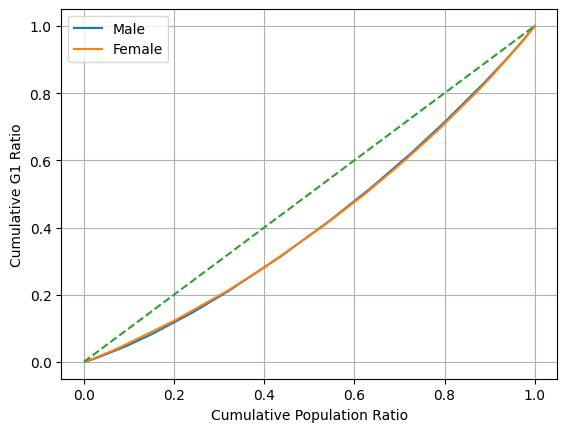

男性のジニ係数: 0.17197351667939903
女性のジニ係数: 0.1723782950865341


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# データ読み込み
student_data_math = pd.read_csv('student-mat.csv', sep=';')

# 男女別データ
male = student_data_math[student_data_math['sex'] == 'M']['G1']
female = student_data_math[student_data_math['sex'] == 'F']['G1']

# 昇順ソート
male = np.sort(male)
female = np.sort(female)

# ローレンツ曲線用データ 男性
male_cum = np.cumsum(male)
male_ratio = male_cum / male_cum[-1]
male_pop = np.arange(1, len(male)+1) / len(male)

# ローレンツ曲線用データ 女性
female_cum = np.cumsum(female)
female_ratio = female_cum / female_cum[-1]
female_pop = np.arange(1, len(female)+1) / len(female)

# ローレンツ曲線
plt.plot(male_pop, male_ratio, label='Male')
plt.plot(female_pop, female_ratio, label='Female')

# 完全平等線
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('Cumulative Population Ratio')
plt.ylabel('Cumulative G1 Ratio')

plt.legend()
plt.grid(True)

plt.show()

def gini(x):
    x = np.array(x)
    mean_x = np.mean(x)
    n = len(x)
    diff_sum = 0

    for i in range(n):
        for j in range(n):
            diff_sum += abs(x[i] - x[j])

    return diff_sum / (2 * (n**2) * mean_x)

male_gini = gini(male)
female_gini = gini(female)

print('男性のジニ係数:', male_gini)
print('女性のジニ係数:', female_gini)

#参考文献https://bellcurve.jp/statistics/course/3798.html